In [1]:
from PIL import Image
from glob import glob
import numpy as np

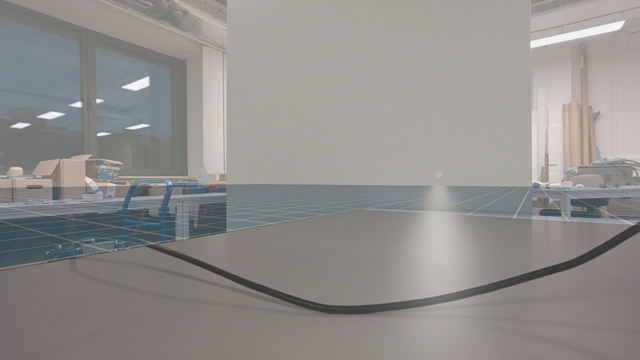

In [2]:
image_real = Image.open("real_background.png").convert("RGBA")
image_sim = Image.open("sim.png").convert("RGBA")
Image.blend(image_sim, image_real, 0.5).convert("RGB")

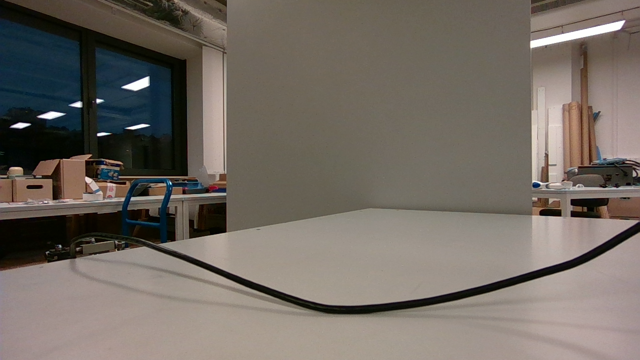

In [3]:
image_real

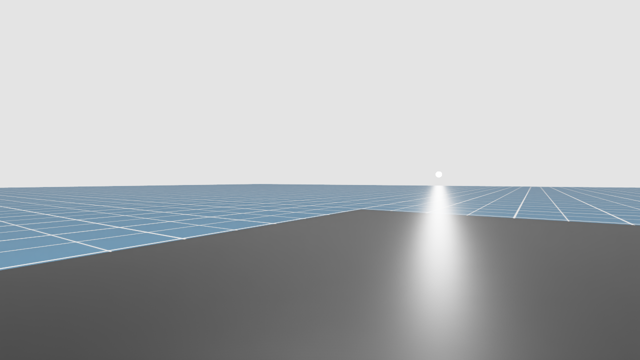

In [4]:
image_sim

In [5]:
import cv2
import matplotlib.pyplot as plt

In [88]:
real = cv2.imread("fun_imgs/0_cur.png")
sim = cv2.imread("sim.png")

In [89]:
def get_edge(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5,5), 1.0)
    edges = cv2.Canny(blurred, threshold1=50, threshold2=150)

    return edges

size=(640,360)

In [90]:
real_edge = get_edge(real)
sim_edge = get_edge(sim)

In [91]:
overlay = np.zeros((size[1], size[0], 3), dtype=np.uint8)
overlay[real_edge > 0] = [255, 0, 0]   # Red edges from image 1
overlay[sim_edge > 0] = [0, 255, 0]   # Green edges from image 2

# Where both overlap, they become yellow
overlay[(real_edge > 0) & (sim_edge > 0)] = [255, 255, 0]

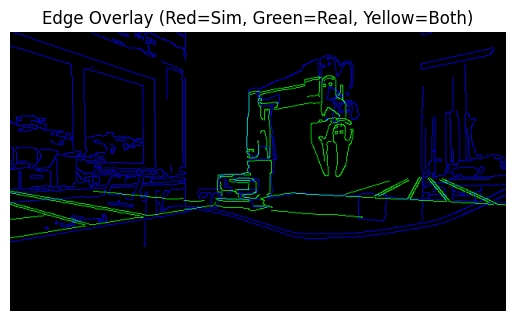

In [92]:
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title("Edge Overlay (Red=Sim, Green=Real, Yellow=Both)")
plt.axis("off")
plt.show()

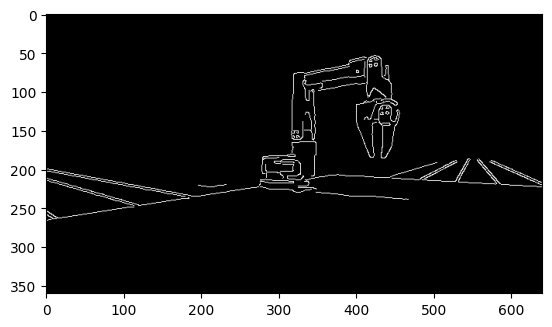

In [86]:
plt.imshow(sim_edge, cmap="gray")

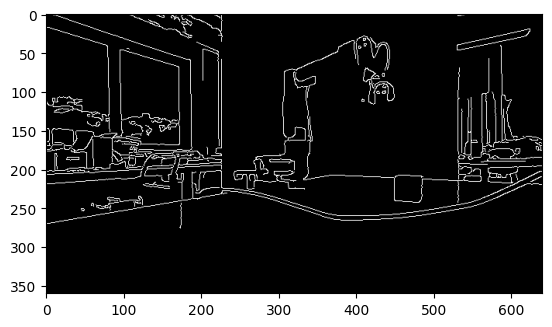

In [87]:
plt.imshow(real_edge, cmap="gray")